In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
import numpy as np
import lingam
from sklearn.preprocessing import StandardScaler
import pygraphviz
from causallearn.search.FCMBased import lingam
# Allow running from anywhere by adding project root (one level up from this file) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.insert(0, project_root)
from features.builder import (
    get_top_concept_ids)

In [5]:
df =pd.read_csv('../scripts/outputs/conditions_named.csv')

In [6]:
s = (
    df.dropna(subset=["condition_names"])
      .assign(condition=df["condition_names"].str.split(r",\s*"))
      .explode("condition")
)

# count how many unique patients had each condition
top10 = (
    s.groupby("condition")["person_id"]
     .nunique()
     .sort_values(ascending=False)
     .head(10)
)

In [13]:
top10.to_frame().reset_index().to_csv('../scripts/outputs/top10_conditions.csv', index=False)

In [17]:
import duckdb
con = duckdb.connect(database="../data/input/mimiciv_omop.db")

In [8]:
con.execute("""CREATE OR REPLACE TABLE result.debug_anchors AS
SELECT
  person_id,
  CAST(condition_start_date AS DATE) AS index_date,
  label
FROM read_csv_auto('../scripts/outputs/mimiciv_creatinine_antonia.csv');""").fetch_df()

,Count
0,150497


In [27]:
y=pd.read_csv('../scripts/outputs/mimiciv_creatinine_antonia.csv')

In [37]:
x = con.execute("""
SELECT * 
FROM result.debug_conditions
""").fetch_df()

In [ ]:
con.execute("""CREATE OR REPLACE TABLE result.debug_conditions AS
SELECT
  a.person_id,
  a.index_date,
  STRING_AGG(DISTINCT CAST(c.condition_concept_id AS VARCHAR), ', ') AS condition_ids
FROM result.debug_anchors a
LEFT JOIN main.condition_occurrence c
  ON c.person_id = a.person_id
 AND c.condition_start_date >= a.index_date - INTERVAL 365 DAY
 AND c.condition_start_date <  a.index_date
GROUP BY a.person_id, a.index_date;""").fetch_df()

,Count
0,150497


In [22]:
con.execute("""CREATE OR REPLACE TABLE result.debug_conditions_counted AS
SELECT
  person_id,
  index_date,
  condition_ids,
  CASE
    WHEN condition_ids IS NULL THEN 0
    ELSE array_length(str_split(condition_ids, ', '))
  END AS condition_id_count
FROM result.debug_conditions;""")

In [24]:
con.execute("""CREATE OR REPLACE TABLE result.debug_conditions_named AS
WITH exploded AS (
  SELECT
    dc.person_id,
    dc.index_date,
    dc.condition_id_count,
    TRY_CAST(trim(x) AS BIGINT) AS concept_id
  FROM result.debug_conditions_counted dc
  CROSS JOIN UNNEST(
    CASE
      WHEN dc.condition_ids IS NULL THEN []
      ELSE str_split(dc.condition_ids, ', ')
    END
  ) AS t(x)
),
joined AS (
  SELECT
    e.person_id,
    e.index_date,
    e.condition_id_count,
    e.concept_id,
    COALESCE(c.concept_name, 'UNKNOWN_' || CAST(e.concept_id AS VARCHAR)) AS concept_name
  FROM exploded e
  LEFT JOIN main.concept c
    ON c.concept_id = e.concept_id
),
dedup AS (
  SELECT DISTINCT
    person_id,
    index_date,
    condition_id_count,
    concept_id,
    concept_name
  FROM joined
)
SELECT
  person_id,
  index_date,
  condition_id_count,

  -- ordered, because we're aggregating after dedup
  STRING_AGG(concept_name, ', ' ORDER BY concept_name) AS condition_names,
  STRING_AGG(CAST(concept_id AS VARCHAR), ', ' ORDER BY concept_id) AS condition_ids

FROM dedup
GROUP BY person_id, index_date, condition_id_count;""")

In [29]:
y[['person_id','label']]

,person_id,label
0,4529936079248104858,1
1,-5406534350319114115,1
2,2482277939881153155,1
3,1354160106766775448,1
4,7125964117376773597,1
...,...,...
150492,-2052704856662982127,0
150493,-4664443779231740354,0
150494,-5235189876787454594,0
150495,-836581256970538236,0


In [35]:
all = con.execute("""SELECT *
FROM result.debug_conditions_named""").fetch_df()

In [40]:
z=x.merge(y[['person_id','label']], on='person_id',how='left')

In [41]:
z[z.label==1]

,person_id,index_date,condition_ids,label
0,3484001056149176746,2139-09-21,"29735, 42537748, 435788, 40321716, 201066, 404...",1
1,-1845793529452034374,2126-06-24,"80180, 432867, 4190307, 320128, 4206148, 41522...",1
2,-3888336484066103892,2143-10-25,"81611, 378253, 132736, 255848, 31967, 437663, ...",1
3,-2557052905850863517,2148-11-06,"136368, 80180, 432867, 257011, 4152280, 404795...",1
6,-5795020960044935140,2129-01-11,"192680, 37311319, 36714559, 442077, 40487064, ...",1
...,...,...,...,...
150481,-4711560632182732913,2141-11-19,None,1
150482,-5086327652978743014,2138-01-30,None,1
150483,2492890826215595860,2112-03-03,None,1
150484,5927614077914097565,2176-06-01,None,1


In [32]:
all=all.merge(y[['person_id','label']], on='person_id',how='left').to_csv('../scripts/outputs/conditions_named.csv', index=False)

In [34]:
pd.read_csv('../scripts/outputs/conditions_named.csv')

,person_id,index_date,condition_id_count,condition_names,condition_ids,label
0,-1197235198095339026,2163-04-22,50,"Acute ischemic heart disease, Acute non-ST seg...","72418, 80502, 81723, 81878, 81902, 140673, 141...",1
1,976442939115589933,2126-01-14,16,"Abnormal body temperature, Acute alcohol intox...","197039, 201907, 320128, 375519, 432875, 433753...",1
2,7256398184651085983,2121-05-11,23,"Acute kidney injury, Apraxia, Atrioventricular...","132342, 197320, 201826, 313226, 316135, 320128...",1
3,-2515438942385023877,2120-12-02,14,"Acute hypoxemic respiratory failure, Acute non...","192450, 320128, 373764, 432867, 432870, 433736...",1
4,5798510674569880721,2129-12-10,14,Acute exacerbation of chronic obstructive pulm...,"31317, 318800, 432867, 433440, 434814, 436659,...",1
...,...,...,...,...,...,...
43685,4349378041463678096,2139-11-08,1,Psychotic disorder,436073,0
43686,-4285942179978540578,2180-08-03,1,Disorder of intestine,201618,0
43687,-227207563059202586,2189-01-24,1,Chest pain,77670,0
43688,3576529411217641946,2122-03-07,1,Pyelonephritis,198199,0


In [8]:
x[x.concept_id == 19069137]

,concept_id,concept_name
139,19069137,bemiparin


In [33]:
x=con.execute("""SELECT * FROM measurement WHERE measurement_concept_id IN (3016723)""").fetch_df()

In [36]:
x.person_id.nunique()z

295111

In [42]:
con.execute("""SELECT COUNT(DISTINCT person_id) AS num_patients_mimic
FROM main.measurement
WHERE measurement_concept_id = 3016723
  AND value_as_number IS NOT NULL
  AND value_as_number < 1.2;   -- choose threshold   -- choose threshold""").fetch_df()

,num_patients_mimic
0,270163


In [32]:
con.execute("""
        WITH high_creat AS (
            SELECT DISTINCT
                person_id
            FROM main.measurement
            WHERE measurement_concept_id = 3016723
              AND value_as_number IS NOT NULL
              AND value_as_number > 1.2
        ),
        low_creat AS (
            SELECT
                person_id,
                measurement_date
            FROM main.measurement
            WHERE measurement_concept_id = 3016723
              AND value_as_number IS NOT NULL
              AND value_as_number < 1.2
        )
        SELECT
            lc.person_id,
            MIN(lc.measurement_date) AS condition_start_date
        FROM low_creat lc
        LEFT JOIN high_creat hc
          ON lc.person_id = hc.person_id
        WHERE hc.person_id IS NULL              -- ensure NEVER high creatinine
        GROUP BY lc.person_id
    """).fetch_df()

,person_id,condition_start_date
0,-513787084287459651,2174-04-21
1,-6474326263455606157,2115-11-15
2,6961083425663732096,2114-11-03
3,7333070847592648943,2185-11-22
4,-5034842304322444602,2145-02-09
...,...,...
221290,-5389339089249609025,2137-04-14
221291,-6034863570536239856,2183-11-13
221292,3123745301076544515,2164-07-31
221293,-786190919266668508,2126-06-11


In [25]:
x.shape

(4911931, 20)

In [26]:
x

,measurement_id,person_id,measurement_concept_id,measurement_date,measurement_datetime,measurement_time,measurement_type_concept_id,operator_concept_id,value_as_number,value_as_concept_id,unit_concept_id,range_low,range_high,provider_id,visit_occurrence_id,visit_detail_id,measurement_source_value,measurement_source_concept_id,unit_source_value,value_source_value
0,5907162596440859596,-2765641899754562290,3016723,2177-09-25,2177-09-25 04:10:00,None,32856,<NA>,NaN,<NA>,8840,0.4,1.1,<NA>,8314261634443701669,<NA>,50912,2000051104,mg/dL,None
1,-9060535483261610992,8795449492300080034,3016723,2153-10-15,2153-10-15 07:05:00,None,32856,<NA>,NaN,<NA>,8840,0.5,1.2,<NA>,7060236094308783128,<NA>,50912,2000051104,mg/dL,None
2,-2745343407325169432,9075533239196798397,3016723,2183-09-01,2183-09-01 14:50:00,None,32856,<NA>,0.1,<NA>,8840,0.5,1.2,<NA>,-4229071906428912322,<NA>,50912,2000051104,mg/dL,0.1
3,3391791681063194834,-5181918535745734413,3016723,2142-01-10,2142-01-10 06:00:00,None,32856,<NA>,0.1,<NA>,8840,0.5,1.2,<NA>,8147684586245966882,<NA>,50912,2000051104,mg/dL,0.1
4,7974222270305518190,-3953631359772172327,3016723,2119-08-15,2119-08-15 15:10:00,None,32817,<NA>,0.2,<NA>,8840,NaN,NaN,<NA>,-2230024671630172545,<NA>,220615,2000030024,mg/dL,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911926,6714200997756694055,6944824663231106940,3016723,2181-05-09,2181-05-09 02:01:00,None,32856,<NA>,NaN,<NA>,8840,0.5,1.2,<NA>,2003773804714985699,<NA>,50912,2000051104,mg/dL,___
4911927,6510107638836820058,6396263092351191934,3016723,2137-08-28,2137-08-28 07:25:00,None,32856,<NA>,NaN,<NA>,8840,0.4,1.1,<NA>,-4529301558268648915,<NA>,50912,2000051104,mg/dL,___
4911928,8452514423924990446,2627806110321856807,3016723,2143-10-14,2143-10-14 16:00:00,None,32856,<NA>,NaN,<NA>,8840,0.5,1.2,<NA>,6044520059741058977,<NA>,50912,2000051104,mg/dL,___
4911929,-1313300668828827686,1119282964879447235,3016723,2147-06-04,2147-06-04 15:38:00,None,32856,<NA>,NaN,<NA>,8840,0.4,1.1,<NA>,-6659117789285769900,<NA>,50912,2000051104,mg/dL,___


In [44]:
df = pd.read_csv("../scripts/outputs/mimiciv_creatinine_nooverlap_cleaned_new_lessfeat.csv")
df.rename(columns={"label": "Increased_Creatinine"}, inplace=True)
# df.drop(columns=["exposure_ibuprofen","exposure_naproxen"], inplace=True)

In [3]:
# df['gender'] = df['gender'].replace({'FEMALE': 0, 'MALE': 1})
# df.drop(columns=['gender'], inplace=True)
# df_encoded = pd.get_dummies(df, columns=['race'], drop_first=False)
# scaler = StandardScaler()
# df['age_at_outcome'] = scaler.fit_transform(df[['age_at_outcome']])

Finished build prior


100%|██████████| 10/10 [02:18<00:00, 13.82s/it]


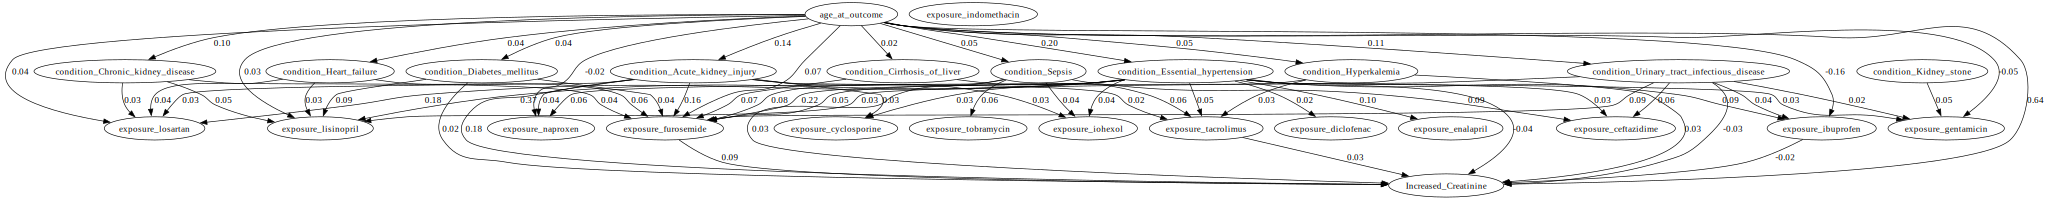

In [47]:
import numpy as np
import pandas as pd
import lingam
from tqdm import tqdm

def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    # Standardize every column to mean 0, std 1 (safe for binary too)
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, 1.0)
    return (df - mu) / sd

def build_prior(df,
                age_col="age_at_outcome",
                y_col="Increased_Creatinine",
                drug_prefix="exposure_",
                cond_prefix="condition_",
                forbid_drug_to_cond=True,
                forbid_y_to_pre=True):
    cols = df.columns.tolist()
    p = len(cols)
    prior = np.zeros((p, p))  # 0 unknown, -1 forbidden, 1 required

    age = cols.index(age_col)
    y = cols.index(y_col)

    is_cond = np.array([c.startswith(cond_prefix) for c in cols])
    is_drug = np.array([c.startswith(drug_prefix) for c in cols])

    # nothing -> age
    prior[:, age] = -1
    prior[age, age] = 0

    # outcome cannot cause pre-outcome vars (use only if truly "pre")
    if forbid_y_to_pre:
        prior[y, is_cond] = -1
        prior[y, is_drug] = -1
        prior[y, age] = -1

    # optionally forbid drugs -> conditions
    if forbid_drug_to_cond:
        prior[is_drug[:, None] & is_cond[None, :]] = -1
    
    print("Finished build prior")

    return prior

def bootstrap_lingam(df_z, prior, n_boot=300, seed=0):
    rng = np.random.default_rng(seed)
    n, p = df_z.shape
    Bs = np.empty((n_boot, p, p), dtype=float)

    for b in tqdm(range(n_boot)):
        idx = rng.integers(0, n, size=n)
        dfb = df_z.iloc[idx].reset_index(drop=True)
        m = lingam.DirectLiNGAM(prior_knowledge=prior)
        m.fit(dfb)
        Bs[b] = m.adjacency_matrix_

    return Bs

def prune_by_stability(Bs, eps=0.10, p_min=0.80, s_min=0.80, use_ci=False, ci=0.95):
    """
    Bs: (B, p, p) bootstrap adjacency matrices
    eps: magnitude threshold (after standardization)
    p_min: selection frequency threshold
    s_min: sign consistency threshold
    use_ci: if True, keep edges whose CI doesn't cross 0 instead of eps+p_min+s_min rules
    """
    B, p, _ = Bs.shape
    abs_B = np.abs(Bs)

    # selection frequency based on eps
    sel = abs_B >= eps
    p_ij = sel.mean(axis=0)

    # sign consistency among selected samples (more stable than using all samples)
    pos = (Bs > 0) & sel
    neg = (Bs < 0) & sel
    pos_rate = np.divide(pos.sum(axis=0), sel.sum(axis=0), out=np.zeros((p, p)), where=sel.sum(axis=0) != 0)
    neg_rate = np.divide(neg.sum(axis=0), sel.sum(axis=0), out=np.zeros((p, p)), where=sel.sum(axis=0) != 0)
    s_ij = np.maximum(pos_rate, neg_rate)

    # typical magnitude and typical signed effect
    m_ij = np.median(abs_B, axis=0)
    med_signed = np.median(Bs, axis=0)

    keep = (p_ij >= p_min) & (s_ij >= s_min) & (m_ij >= eps)

    if use_ci:
        lo = np.quantile(Bs, (1-ci)/2, axis=0)
        hi = np.quantile(Bs, 1-(1-ci)/2, axis=0)
        keep = (lo > 0) | (hi < 0)   # CI does not cross 0

    B_pruned = np.where(keep, med_signed, 0.0)
    return B_pruned, p_ij, s_ij, m_ij

# ---- Usage ----
# 1) standardize
df_z = standardize_df(df)

# 2) constraints
prior = build_prior(df_z,
                    age_col="age_at_outcome",
                    y_col="Increased_Creatinine",
                    forbid_drug_to_cond=True,
                    forbid_y_to_pre=True)

# 3) bootstrap
Bs = bootstrap_lingam(df_z, prior, n_boot=10, seed=0)

# 4) prune (defaults similar to what you pasted)
B_pruned, freq, sign_cons, mag_med = prune_by_stability(
    Bs, eps=0.02, p_min=0.80, s_min=0.80, use_ci=False
)

# 5) visualize (optional: also apply top-k per child AFTER stability)
from lingam.utils import make_dot
dot = make_dot(B_pruned, labels=df_z.columns.tolist())
dot


In [18]:
import numpy as np
import pandas as pd

def all_effects_dataframe(
    B_pruned: np.ndarray,
    Bs: np.ndarray,
    feature_names: list[str],
    eps: float = 0.03,
    ci: float = 0.95,
    drop_zero_pruned: bool = False
) -> pd.DataFrame:
    """
    Build a dataframe of ALL direct causal effects:
    feature_j -> feature_i  (B[i, j])
    """
    cols = feature_names
    p = len(cols)
    B = Bs.shape[0]

    records = []

    for i in range(p):        # target (child)
        for j in range(p):    # source (parent)
            if i == j:
                continue

            # Orientation: B[i, j] = j -> i
            pruned_eff = B_pruned[i, j]
            w = Bs[:, i, j]

            # stability stats
            sel = np.abs(w) >= eps
            freq = sel.mean()

            sign_cons = 0.0
            if sel.sum() > 0:
                sign_cons = max((w[sel] > 0).mean(), (w[sel] < 0).mean())

            med = np.median(w)
            mean = np.mean(w)
            mag_med = np.median(np.abs(w))

            lo = np.quantile(w, (1 - ci) / 2)
            hi = np.quantile(w, 1 - (1 - ci) / 2)

            if drop_zero_pruned and pruned_eff == 0:
                continue

            records.append({
                "source": cols[j],
                "target": cols[i],
                "pruned_effect": pruned_eff,
                # "bootstrap_median_effect": med,
                # "bootstrap_mean_effect": mean,
                # "bootstrap_median_abs_effect": mag_med,
                # "selection_freq": freq,
                # "sign_consistency": sign_cons,
                # f"ci{int(ci*100)}_lo": lo,
                # f"ci{int(ci*100)}_hi": hi,
                # "ci_excludes_0": (lo > 0) | (hi < 0),
                # "sign": int(np.sign(med))
            })

    df_all = pd.DataFrame.from_records(records)

    # # ranking score (use pruned if available, else bootstrap magnitude)
    # score = df_all["pruned_effect"].abs()
    # score_alt = df_all["bootstrap_median_abs_effect"]
    # df_all["rank_score"] = np.where(score > 0, score, score_alt)

    df_all = df_all.sort_values("pruned_effect", ascending=False).reset_index(drop=True)
    df_all.insert(0, "rank", np.arange(1, len(df_all) + 1))

    return df_all


In [48]:
effects_all_df = all_effects_dataframe(
    B_pruned=B_pruned,
    Bs=Bs,
    feature_names=df.columns.tolist(),
    eps=0,
    ci=0.95,
    drop_zero_pruned=False   # True = only edges shown in graph
)

# effects_all_df.to_csv("all_feature_effects.csv", index=False)
effects_all_df


,rank,source,target,pruned_effect
0,1,age_at_outcome,Increased_Creatinine,0.636470
1,2,condition_Essential_hypertension,exposure_lisinopril,0.373169
2,3,condition_Essential_hypertension,exposure_furosemide,0.217601
3,4,age_at_outcome,condition_Essential_hypertension,0.202249
4,5,condition_Essential_hypertension,exposure_losartan,0.184360
...,...,...,...,...
645,646,exposure_ibuprofen,Increased_Creatinine,-0.024594
646,647,condition_Urinary_tract_infectious_disease,Increased_Creatinine,-0.031453
647,648,condition_Essential_hypertension,Increased_Creatinine,-0.036847
648,649,age_at_outcome,exposure_gentamicin,-0.047658


In [20]:
furo_out = (
    effects_all_df
    .query("source == 'exposure_furosemide'")
    .sort_values("pruned_effect", ascending=False)
)
furo_out.head(10)

,rank,source,target,pruned_effect
11,12,exposure_furosemide,Increased_Creatinine,0.090276
357,358,exposure_furosemide,exposure_naproxen,0.000000
594,595,exposure_furosemide,exposure_gentamicin,0.000000
578,579,exposure_furosemide,exposure_tobramycin,0.000000
572,573,exposure_furosemide,exposure_lisinopril,0.000000
538,539,exposure_furosemide,exposure_tacrolimus,0.000000
534,535,exposure_furosemide,exposure_cyclosporine,0.000000
515,516,exposure_furosemide,exposure_losartan,0.000000
479,480,exposure_furosemide,exposure_ceftazidime,0.000000
463,464,exposure_furosemide,exposure_indomethacin,0.000000


In [34]:
to_furo = (
    effects_all_df
    .query("target == 'exposure_furosemide'")
    .sort_values("pruned_effect", ascending=False)
)

to_furo.head(10)


,rank,source,target,pruned_effect
2,3,condition_Essential_hypertension,exposure_furosemide,0.217601
6,7,condition_Acute_kidney_injury,exposure_furosemide,0.160365
15,16,condition_Urinary_tract_infectious_disease,exposure_furosemide,0.086136
16,17,condition_Sepsis,exposure_furosemide,0.079952
17,18,condition_Cirrhosis_of_liver,exposure_furosemide,0.074526
18,19,age_at_outcome,exposure_furosemide,0.065886
22,23,condition_Heart_failure,exposure_furosemide,0.059723
26,27,condition_Hyperkalemia,exposure_furosemide,0.049468
33,34,condition_Chronic_kidney_disease,exposure_furosemide,0.040286
35,36,condition_Diabetes_mellitus,exposure_furosemide,0.039614


In [29]:
to_creat = (
    effects_all_df
    .query("target == 'Increased_Creatinine'")
    .sort_values("pruned_effect", ascending=False)
)
to_creat = to_creat[to_creat['pruned_effect'] != 0]

In [31]:
to_creat

,rank,source,target,pruned_effect
0,1,age_at_outcome,Increased_Creatinine,0.636470
5,6,condition_Acute_kidney_injury,Increased_Creatinine,0.184286
11,12,exposure_furosemide,Increased_Creatinine,0.090276
47,48,exposure_tacrolimus,Increased_Creatinine,0.029528
51,52,condition_Hyperkalemia,Increased_Creatinine,0.026015
52,53,condition_Sepsis,Increased_Creatinine,0.025832
58,59,condition_Diabetes_mellitus,Increased_Creatinine,0.021008
645,646,exposure_ibuprofen,Increased_Creatinine,-0.024594
646,647,condition_Urinary_tract_infectious_disease,Increased_Creatinine,-0.031453
647,648,condition_Essential_hypertension,Increased_Creatinine,-0.036847


In [30]:
furo_parents = set(to_furo["source"])
creat_parents = set(to_creat["source"])

shared = sorted(furo_parents & creat_parents)

shared


['age_at_outcome',
 'condition_Acute_kidney_injury',
 'condition_Diabetes_mellitus',
 'condition_Essential_hypertension',
 'condition_Hyperkalemia',
 'condition_Sepsis',
 'condition_Urinary_tract_infectious_disease',
 'exposure_ibuprofen',
 'exposure_tacrolimus']

In [33]:
rows = []

for feat in shared:
    furo_row = to_furo[to_furo["source"] == feat].iloc[0]
    creat_row = to_creat[to_creat["source"] == feat].iloc[0]

    rows.append({
        "feature": feat,
        "to_furosemide": furo_row["pruned_effect"],
        "to_creatinine": creat_row["pruned_effect"],
        "abs_to_furo": abs(furo_row["pruned_effect"]),
        "abs_to_creat": abs(creat_row["pruned_effect"]),
    })

shared_df = (
    pd.DataFrame(rows)
    .sort_values("abs_to_creat", ascending=False)
    .reset_index(drop=True)
)

shared_df


,feature,to_furosemide,to_creatinine,abs_to_furo,abs_to_creat
0,age_at_outcome,0.065886,0.636470,0.065886,0.636470
1,condition_Acute_kidney_injury,0.160365,0.184286,0.160365,0.184286
2,condition_Essential_hypertension,0.217601,-0.036847,0.217601,0.036847
3,condition_Urinary_tract_infectious_disease,0.086136,-0.031453,0.086136,0.031453
4,exposure_tacrolimus,0.000000,0.029528,0.000000,0.029528
5,condition_Hyperkalemia,0.049468,0.026015,0.049468,0.026015
6,condition_Sepsis,0.079952,0.025832,0.079952,0.025832
7,exposure_ibuprofen,0.000000,-0.024594,0.000000,0.024594
8,condition_Diabetes_mellitus,0.039614,0.021008,0.039614,0.021008


In [ ]:
to_furo = to_furo[to_furo.pruned_effect != 0]
furo_parents = set(to_furo["source"])
creat_parents = set(to_creat["source"])

furo_only = sorted(furo_parents - creat_parents)

rows = []

for feat in furo_only:
    row = to_furo[to_furo["source"] == feat].iloc[0]
    rows.append({
        "feature": feat,
        "to_furosemide": row["pruned_effect"],
        "abs_to_furo": abs(row["pruned_effect"]),
    })

furo_only_df = (
    pd.DataFrame(rows)
    .sort_values("abs_to_furo", ascending=False)
    .reset_index(drop=True) 
)

furo_only_df


,feature,to_furosemide,abs_to_furo
0,condition_Cirrhosis_of_liver,0.074526,0.074526
1,condition_Heart_failure,0.059723,0.059723
2,condition_Chronic_kidney_disease,0.040286,0.040286


In [ ]:
import numpy as np
import pandas as pd


def effects_table_to_target_correct(
    B_pruned: np.ndarray,
    Bs: np.ndarray,
    feature_names: list[str],
    target: str = "Increased_Creatinine",
    min_keep_only: bool = True,
    add_ci: bool = True,
    ci: float = 0.95
) -> pd.DataFrame:
    cols = feature_names
    p = len(cols)
    t = cols.index(target)

    # Correct orientation: effect(feature -> target) is B[target, feature]
    pruned_eff = B_pruned[t, :].copy()         # length p
    boot_eff   = Bs[:, t, :]                   # shape (B, p)

    med_eff  = np.median(boot_eff, axis=0)
    mean_eff = np.mean(boot_eff, axis=0)
    mag_med  = np.median(np.abs(boot_eff), axis=0)

    df_out = pd.DataFrame({
        "feature": cols,
        "target": target,
        "pruned_effect": pruned_eff,
        # "bootstrap_median_effect": med_eff,
        # "bootstrap_mean_effect": mean_eff,
        # "bootstrap_median_abs_effect": mag_med,
        # "sign": np.sign(med_eff).astype(int),
    })

    # if add_ci:
    #     lo = np.quantile(boot_eff, (1 - ci) / 2, axis=0)
    #     hi = np.quantile(boot_eff, 1 - (1 - ci) / 2, axis=0)
    #     df_out[f"ci{int(ci*100)}_lo"] = lo
    #     df_out[f"ci{int(ci*100)}_hi"] = hi
    #     df_out["ci_excludes_0"] = (lo > 0) | (hi < 0)

    # drop the target itself
    df_out = df_out[df_out["feature"] != target].copy()

    if min_keep_only:
        df_out = df_out[df_out["pruned_effect"] != 0].copy()

    df_out["rank_score"] = df_out["pruned_effect"].abs()
    df_out = df_out.sort_values("rank_score", ascending=False).reset_index(drop=True)
    df_out.insert(0, "rank", np.arange(1, len(df_out) + 1))

    return df_out


In [17]:
effects_df = effects_table_to_target_correct(
    B_pruned=B_pruned,
    Bs=Bs,
    feature_names=df.columns.tolist(),
    target="Increased_Creatinine",
    min_keep_only=False  # set True if you only want nonzero pruned edges
)

effects_df.to_csv("effects_to_increased_creatinine_anastasia.csv", index=False)
effects_df.head(20)



,rank,feature,target,pruned_effect,rank_score
0,1,age_at_outcome,Increased_Creatinine,0.636470,0.636470
1,2,condition_Acute_kidney_injury,Increased_Creatinine,0.184286,0.184286
2,3,exposure_furosemide,Increased_Creatinine,0.090276,0.090276
3,4,condition_Essential_hypertension,Increased_Creatinine,-0.036847,0.036847
4,5,condition_Urinary_tract_infectious_disease,Increased_Creatinine,-0.031453,0.031453
5,6,exposure_tacrolimus,Increased_Creatinine,0.029528,0.029528
6,7,condition_Hyperkalemia,Increased_Creatinine,0.026015,0.026015
7,8,condition_Sepsis,Increased_Creatinine,0.025832,0.025832
8,9,exposure_ibuprofen,Increased_Creatinine,-0.024594,0.024594
9,10,condition_Diabetes_mellitus,Increased_Creatinine,0.021008,0.021008


In [72]:
effects_df.head(20)

,rank,feature,target,pruned_effect,bootstrap_median_effect,bootstrap_mean_effect,bootstrap_median_abs_effect,selection_freq,sign_consistency,sign,ci95_lo,ci95_hi,ci_excludes_0,rank_score
0,1,age_at_outcome,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
1,2,exposure_prednisolone,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
2,3,exposure_flucytosine,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
3,4,exposure_ranolazine,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
4,5,exposure_ascorbic_acid,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
5,6,"exposure_albumin_human,_USP",Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
6,7,exposure_hydrochlorothiazide,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
7,8,exposure_betamethasone,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
8,9,exposure_irbesartan,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0
9,10,exposure_olmesartan,Increased_Creatinine,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,False,0.0


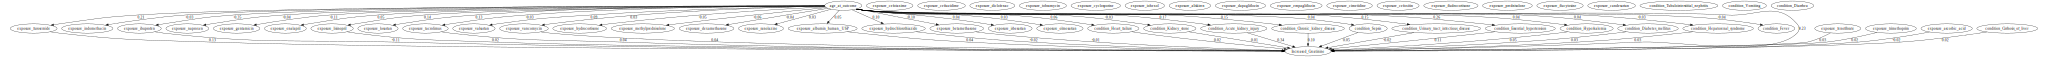

In [5]:
import numpy as np
import pandas as pd
import lingam

def build_minimal_prior(df: pd.DataFrame,
                        age_col="age_at_outcome",
                        y_col="Increased_Creatinine") -> np.ndarray:
    """
    Minimal prior knowledge:
      1) Nothing -> age_col   (age has no parents)
      2) y_col -> nothing     (outcome has no children; cannot cause any variable)
    """
    cols = df.columns.tolist()
    p = len(cols)
    prior = np.zeros((p, p), dtype=int)  # 0 unknown, -1 forbidden, 1 required

    age = cols.index(age_col)
    y = cols.index(y_col)

    # 1) Nothing can cause age: forbid all edges into age (i -> age)
    prior[:, age] = -1
    prior[age, age] = 0  # diagonal irrelevant

    # 2) Outcome cannot cause anything: forbid all edges out of y (y -> j)
    prior[y, :] = -1
    prior[y, y] = 0

    return prior

# --- Run LiNGAM (single fit) ---
# Optional but recommended: standardize so coefficients are comparable
def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, 1.0)
    return (df - mu) / sd

df_z = standardize_df(df)

prior = build_minimal_prior(df_z,
                            age_col="age_at_outcome",
                            y_col="Increased_Creatinine")

def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    mu = df.mean(axis=0)
    sd = df.std(axis=0, ddof=0).replace(0, 1.0)
    return (df - mu) / sd

df_z = standardize_df(df)
model = lingam.DirectLiNGAM(prior_knowledge=prior)
model.fit(df_z)

B = model.adjacency_matrix_

# visualize
from lingam.utils import make_dot
dot = make_dot(B, labels=df_z.columns.tolist())
dot


In [ ]:
import numpy as np
import lingam

cols = df.columns.tolist()
p = len(cols)
prior = np.zeros((p, p))

age = cols.index("age_at_outcome")
y = cols.index("Increased_Creatinine")

is_cond = np.array([c.startswith("condition_") for c in cols])
is_drug = np.array([c.startswith("exposure_") for c in cols])

# 1) nothing -> age
prior[:, age] = -1
prior[age, age] = 0

# 2) outcome cannot cause pre-outcome vars
prior[y, is_cond] = -1
prior[y, is_drug] = -1
prior[y, age] = -1

# 3) (optional) coarse tiering:
#    forbid drugs -> conditions (if diagnoses are defined before drugs in your data)
prior[is_drug[:, None] & is_cond[None, :]] = -1

#    forbid anything -> outcome? (NO) don't do that; you want parents of outcome allowed.

model = lingam.DirectLiNGAM(prior_knowledge=prior)
model.fit(df)
B = model.adjacency_matrix_


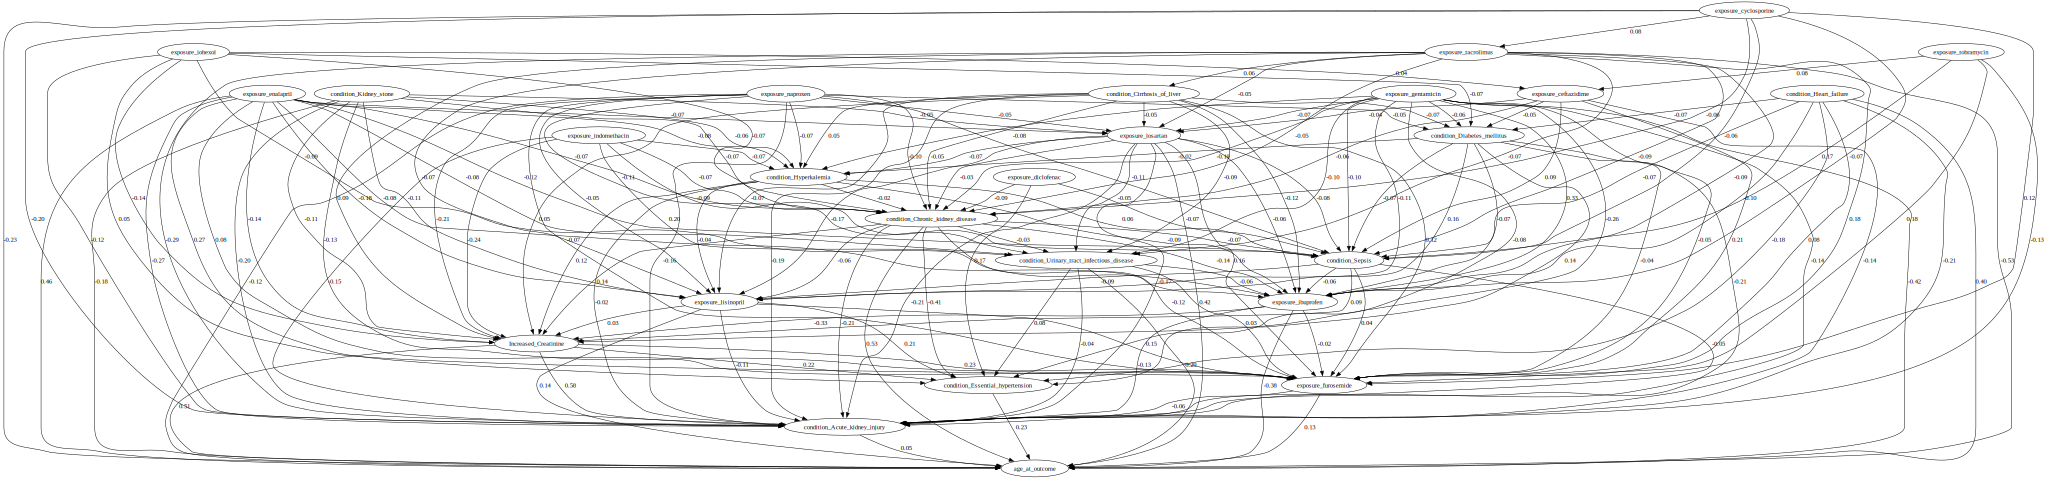

In [8]:
from lingam.utils import make_dot

dot = make_dot(B,labels=df.columns.tolist())
dot

In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from lingam.utils import make_dot  # only for plotting

# 1) Use your exact column order
cols = [
    # 'age_at_outcome',
    'exposure_furosemide',
    'exposure_ibuprofen',
    'exposure_tacrolimus',
    'exposure_naproxen',
    'exposure_cyclosporine',
    'condition_Heart_failure',
    'condition_Chronic_kidney_disease',
    'condition_Diabetes_mellitus',
    'condition_Essential_hypertension',
    'condition_Calcium_[Mass/volume]_in_Serum_or_Plasma',
    'condition_Acute_renal_failure_syndrome',
    'condition_Sepsis',
    'condition_Urinary_tract_infectious_disease',
    'condition_Injury_of_kidney',
    'Increased_Creatinine'
]
df_use = df[cols].copy()

# 2) Parents = translation of the expert DAG using *your* columns
parents = {
    # 'age_at_outcome': [],

    # indication -> furosemide
    'exposure_furosemide': [
        'condition_Heart_failure',
        'condition_Chronic_kidney_disease',
        'condition_Essential_hypertension',
        'condition_Diabetes_mellitus',
        'condition_Injury_of_kidney',
        # 'age_at_outcome'
    ],

    # “coadministration with NSAIDs” expanded to the NSAIDs you have
    'exposure_ibuprofen':  ['exposure_furosemide'],
    'exposure_naproxen':   ['exposure_furosemide'],

    # calcineurin inhibitors present as individual drugs
    # 'exposure_tacrolimus': ['age_at_outcome'],
    # 'exposure_cyclosporine':['age_at_outcome'],

    # diseases (minimal plausible subset)
    # 'condition_Essential_hypertension': ['age_at_outcome'],
    # 'condition_Diabetes_mellitus': ['age_at_outcome'],
    'condition_Chronic_kidney_disease': [
        'condition_Diabetes_mellitus',
        'condition_Essential_hypertension',
        # 'age_at_outcome'
    ],
    # 'condition_Heart_failure': [
    #     'condition_Essential_hypertension',
    #     'condition_Chronic_kidney_disease',
    #     'age_at_outcome'
    # ],
    # 'condition_Acute_renal_failure_syndrome': [
    #     'condition_Sepsis','condition_Heart_failure','condition_Chronic_kidney_disease'
    # ],
    # 'condition_Injury_of_kidney': [
    #     'condition_Sepsis','condition_Heart_failure','condition_Chronic_kidney_disease'
    # ],
    # 'condition_Sepsis': ['age_at_outcome'],
    # 'condition_Urinary_tract_infectious_disease': ['age_at_outcome'],
    # 'condition_Calcium_[Mass/volume]_in_Serum_or_Plasma': ['age_at_outcome'],

    # outcome: direct parents per expert DAG (translated)
    'Increased_Creatinine': [
        'exposure_furosemide',
        'exposure_ibuprofen',
        'exposure_naproxen',
        'exposure_tacrolimus',
        'exposure_cyclosporine',
        'condition_Chronic_kidney_disease',
        'condition_Acute_renal_failure_syndrome',
        'condition_Injury_of_kidney',
        'condition_Heart_failure',
        'condition_Essential_hypertension',
        'condition_Sepsis',
        'condition_Urinary_tract_infectious_disease',
        'condition_Diabetes_mellitus',
        'condition_Calcium_[Mass/volume]_in_Serum_or_Plasma'
    ],
}

# 3) Fit a linear SEM (weights only on specified edges)
X = df_use.values
name_to_idx = {c:i for i,c in enumerate(cols)}
p = len(cols)
B = np.zeros((p, p))  # rows = cause, cols = effect

for child, par_names in parents.items():
    j = name_to_idx[child]
    if not par_names:
        continue
    P = [name_to_idx[n] for n in par_names]
    reg = LinearRegression().fit(X[:, P], X[:, j])
    B[P, j] = reg.coef_

B_df = pd.DataFrame(B, index=cols, columns=cols)
print("Direct effects into Increased_Creatinine:")
print(B_df['Increased_Creatinine'].sort_values(ascending=False))

# 4) Plot exactly this structure
dot = make_dot(B.T, labels=cols)
# dot.render("exact_expert_graph_weights", format="png", cleanup=True)
dot


KeyError: "['condition_Calcium_[Mass/volume]_in_Serum_or_Plasma', 'condition_Acute_renal_failure_syndrome', 'condition_Injury_of_kidney'] not in index"

In [34]:
# ------------- imports -------------
import numpy as np
import pandas as pd

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ------------- 1. Subset and clean data -------------

# Keep only the columns we care about for now
cols = [
    'exposure_furosemide',
    'exposure_ibuprofen',
    'exposure_tacrolimus',
    'exposure_naproxen',
    'exposure_cyclosporine',
    'condition_Heart_failure',
    'condition_Chronic_kidney_disease',
    'condition_Diabetes_mellitus',
    'condition_Essential_hypertension',
    'condition_Calcium_[Mass/volume]_in_Serum_or_Plasma',
    'condition_Acute_renal_failure_syndrome',
    'condition_Sepsis',
    'condition_Urinary_tract_infectious_disease',
    'condition_Injury_of_kidney',
    'Increased_Creatinine'
]
df_use = df[cols].dropna().copy()  # simple dropna for the example

# Treatment: Furosemide exposure (0/1)
T = df_use['exposure_furosemide'].astype(int).values

# Outcome: Increased Creatinine (0/1 as float)
Y = df_use['Increased_Creatinine'].astype(float).values

# Confounders/controls X = all other variables except treatment & outcome
conf_cols = [
    'exposure_ibuprofen',
    'exposure_tacrolimus',
    'exposure_naproxen',
    'exposure_cyclosporine',
    'condition_Heart_failure',
    'condition_Chronic_kidney_disease',
    'condition_Diabetes_mellitus',
    'condition_Essential_hypertension',
    'condition_Calcium_[Mass/volume]_in_Serum_or_Plasma',
    'condition_Acute_renal_failure_syndrome',
    'condition_Sepsis',
    'condition_Urinary_tract_infectious_disease',
    'condition_Injury_of_kidney',
]
X = df_use[conf_cols].values

# Optional: standardize continuous confounders (age, maybe labs) inside a pipeline
# For RandomForest it's less critical, but harmless.
model_t = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    random_state=0
)
model_y = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=20,
    random_state=0
)

# ------------- 2. Fit CausalForestDML -------------

est = CausalForestDML(
    model_t=model_t,
    model_y=model_y,
    n_estimators=500,            # causal forest trees
    min_samples_leaf=10,
    max_depth=None,
    discrete_treatment=True,     # because Furosemide is 0/1
    random_state=0
)

est.fit(Y, T, X=X)

# ------------- 3. Get main causal ML outputs -------------

# (a) Average Treatment Effect (ATE)
ate = est.ate_.item()
ate_ci = est.ate_interval(X)

print("ATE (Furosemide → Increased Creatinine):", ate)
print("95% CI:", ate_ci)

# (b) Individual Treatment Effects (ITE) for each patient
ite = est.effect(X)   # shape: (n_samples,)
df_use['furosemide_effect'] = ite

print("\nExample individual effects for first 5 patients:")
print(df_use[['exposure_furosemide', 'Increased_Creatinine', 'furosemide_effect']].head())

# (c) Subgroup effects, e.g. for Heart Failure vs no HF

mask_hf = df_use['condition_Heart_failure'] == 1
mask_no_hf = df_use['condition_Heart_failure'] == 0

cate_hf = est.effect(X[mask_hf]).mean()
cate_no_hf = est.effect(X[mask_no_hf]).mean()

print("\nCATE for patients WITH heart failure:", cate_hf)
print("CATE for patients WITHOUT heart failure:", cate_no_hf)


/opt/anaconda3/envs/ade-python/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/ade-python/lib/python3.10/site-packages/econml/dml/dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)
/opt/anaconda3/envs/ade-python/lib/python3.10/site-packages/econml/dml/dml.py:51: UserWarning: First stage model has discrete target but model is not a classifier!
  warn('First stage model has discrete target but model is not a classifier!', UserWarning)


ATE (Furosemide → Increased Creatinine): 0.33892275342668776
95% CI: (0.3228206378504642, 0.38071697985979724)

Example individual effects for first 5 patients:
   exposure_furosemide  Increased_Creatinine  furosemide_effect
0                    0                     1           0.012963
1                    0                     1           0.012963
2                    0                     1           0.007168
3                    0                     1           0.007204
4                    0                     1           0.012963

CATE for patients WITH heart failure: 0.4624646044491668
CATE for patients WITHOUT heart failure: 0.3502399295219094


In [41]:
df_use[df_use['exposure_furosemide'] ==1]

,exposure_furosemide,exposure_ibuprofen,exposure_tacrolimus,exposure_naproxen,exposure_cyclosporine,condition_Heart_failure,condition_Chronic_kidney_disease,condition_Diabetes_mellitus,condition_Essential_hypertension,condition_Calcium_[Mass/volume]_in_Serum_or_Plasma,condition_Acute_renal_failure_syndrome,condition_Sepsis,condition_Urinary_tract_infectious_disease,condition_Injury_of_kidney,Increased_Creatinine,furosemide_effect
2534,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.560324
2535,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.560324
2536,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.560324
2537,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.560324
2538,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.560324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4224,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.560324
4262,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.560324
4341,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.560324
4385,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.560324


In [12]:
from sklearn.linear_model import LinearRegression
import pandas as pd

def residualize(df, parents):
    df_res = pd.DataFrame(index=df.index)
    
    for node in df.columns:
        par_list = parents.get(node, [])
        
        if not par_list:
            # exogenous variable → keep as is
            df_res[node] = df[node].astype(float)
        else:
            reg = LinearRegression().fit(df[par_list], df[node])
            df_res[node] = df[node] - reg.predict(df[par_list])
    
    return df_res


In [3]:
X = df.drop(columns=['Increased_Creatinine'])
X_clean = residualize(X, parents)
y = df['Increased_Creatinine']


NameError: name 'residualize' is not defined

In [40]:
feature_order = [
    "gender",
    "race",
    "age_at_outcome",

    # exposures
    "exposure_furosemide",
    # "exposure_ibuprofen",
    "exposure_tacrolimus",
    # "exposure_naproxen",
    "exposure_cyclosporine",

    # conditions (confounders / mediators)
    "condition_Heart_failure",
    "condition_Chronic_kidney_disease",
    "condition_Diabetes_mellitus",
    "condition_Essential_hypertension",
    "condition_Acute_renal_failure_syndrome",
    "condition_Injury_of_kidney",

    # other causes of increased creatinine
    "condition_Sepsis",
    "condition_Urinary_tract_infectious_disease",
]
y = df["Increased_Creatinine"].values
X = df[feature_order].values

confounders = [
    "condition_Heart_failure", "condition_Chronic_kidney_disease", "condition_Diabetes_mellitus", "condition_Essential_hypertension",
    "condition_Acute_renal_failure_syndrome", "condition_Injury_of_kidney"
]

mediators = [
    # "exposure_furosemide",
    # "exposure_ibuprofen",
    # "exposure_tacrolimus",
    # "exposure_naproxen",
    # "exposure_cyclosporine",
]

other_causes_Y = [
    "condition_Sepsis",
    "condition_Urinary_tract_infectious_disease",
    "exposure_cyclosporine",
    "exposure_tacrolimus",

]

interaction_constraints = [
    ["exposure_furosemide"] + confounders + mediators,
    other_causes_Y,
]


furo_block = [
    "exposure_furosemide",
    "gender", "race", "age_at_outcome",
    "exposure_ibuprofen", "exposure_tacrolimus",
    "exposure_naproxen", "exposure_cyclosporine",
    "condition_Heart_failure",
    "condition_Chronic_kidney_disease",
    "condition_Diabetes_mellitus",
    "condition_Essential_hypertension",
    "condition_Acute_renal_failure_syndrome",
    "condition_Injury_of_kidney",
]
infection_block = [
    "condition_Sepsis",
    "condition_Urinary_tract_infectious_disease",
]

monotone = [
    0,   # gender
    0,   # race
    +1,  # age_at_outcome

    +2,  # exposure_furosemide
    # +0,  # exposure_ibuprofen
    +0,  # exposure_tacrolimus
    # +0,  # exposure_naproxen
    +1,  # exposure_cyclosporine

    +1,  # condition_Heart_failure
    +1,  # condition_Chronic_kidney_disease
    +1,  # condition_Diabetes_mellitus
    +1,  # condition_Essential_hypertension
    +1,  # condition_Acute_renal_failure_syndrome
    +1,  # condition_Injury_of_kidney

    +2,  # condition_Sepsis
    +2,  # condition_Urinary_tract_infectious_disease
]

monotone_constraints = "(" + ",".join(str(m) for m in monotone) + ")"


In [41]:
from sklearn.model_selection import train_test_split
y = df['Increased_Creatinine']
X = df.drop(columns=['Increased_Creatinine'])
X.drop(columns=['condition_Calcium_[Mass/volume]_in_Serum_or_Plasma'], inplace=True)
X['race'].replace({'Black or African American':0, 'White':1, 'Asian':2, 'No matching concept':3}, inplace=True)
X['gender'].replace({'MALE':0,'FEMALE':1},inplace=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

/var/folders/hy/dsg8m4bd0bq1_39z61sbhrlr0000gn/T/ipykernel_66745/3552143965.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['race'].replace({'Black or African American':0, 'White':1, 'Asian':2, 'No matching concept':3}, inplace=True)
/var/folders/hy/dsg8m4bd0bq1_39z61sbhrlr0000gn/T/ipykernel_66745/3552143965.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future be

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


import xgboost as xgb

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=4,
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    # interaction_constraints=interaction_constraints,
    # monotone_constraints=monotone_constraints,
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [49]:
from sklearn.metrics import accuracy_score
print("Train accuracy:", accuracy_score(model.predict(X_train), y_train))
print("Test accuracy:", accuracy_score(model.predict(X_test), y_test))

Train accuracy: 0.8593406593406593
Test accuracy: 0.8331503841931943


In [50]:
importance_df = pd.DataFrame({
        'Feature': model.get_booster().feature_names,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [51]:
importance_df

,Feature,Importance
0,exposure_tacrolimus,0.269976
1,exposure_furosemide,0.144052
2,race,0.137334
3,age_at_outcome,0.127184
4,condition_Essential_hypertension,0.102891
5,condition_Heart_failure,0.071521
6,condition_Sepsis,0.053260
7,condition_Injury_of_kidney,0.044481
8,exposure_cyclosporine,0.039437
9,gender,0.009863


In [46]:
from sklearn.inspection import PartialDependenceDisplay

/opt/anaconda3/envs/causal/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


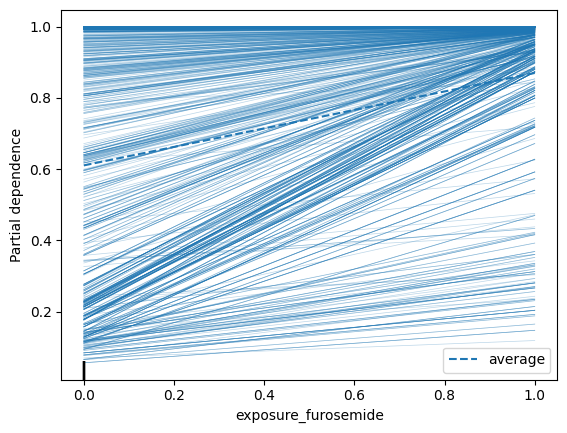

In [52]:
PartialDependenceDisplay.from_estimator(
                model,
                X_test,
                features=['exposure_furosemide'],   # original column name
                kind="both"            # PDP + ICE
            )

In [51]:
import shap
# booster = model.get_booster()

# explainer = shap.TreeExplainer(booster)
# shap_values = explainer(X_test)
# shap.plots.beeswarm(shap_values)
explainer = shap.TreeExplainer(
    model,
    X_test  # background dataset
)

ValueError: could not convert string to float: '[6.379121E-1]'

In [ ]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc'
)

clf.fit(X_clean.drop(columns=['condition_Calcium_[Mass/volume]_in_Serum_or_Plasma']), df['Increased_Creatinine'])


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gender: object, race: object

In [25]:
pred = clf.predict(X_clean.drop(columns=['condition_Calcium_[Mass/volume]_in_Serum_or_Plasma']))


In [28]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(df['Increased_Creatinine'], pred)
print("Accuracy:", accuracy)

Accuracy: 0.8246539222148979


In [33]:
importances = clf.feature_importances_

# Build and sort the importance DataFrame
importance_df = pd.DataFrame({
    'Feature': X_clean.drop(columns=['condition_Calcium_[Mass/volume]_in_Serum_or_Plasma']).columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

In [34]:
importance_df

,Feature,Importance
0,exposure_tacrolimus,0.271162
1,exposure_ibuprofen,0.235690
2,exposure_naproxen,0.232721
3,condition_Heart_failure,0.080826
4,exposure_furosemide,0.056061
5,exposure_cyclosporine,0.052692
6,condition_Essential_hypertension,0.032505
7,condition_Injury_of_kidney,0.020041
8,condition_Sepsis,0.018302
9,condition_Chronic_kidney_disease,0.000000


In [20]:
import duckdb
con = duckdb.connect("../data/input/database-1M_filtered.duckdb")

In [21]:
df = con.execute("SELECT * FROM concept").fetch_df()

In [38]:
df[df.concept_id == 37311319]

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason


In [ ]:
df[df['concept_name'].str.contains('ceftazidime', case=False, na=False)]

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
